<a href="https://colab.research.google.com/github/nguyentrongnguyen3004-eng/DeepLearning_Chest_X_Ray/blob/main/So_s%C3%A1nh_%E1%BA%A3nh_X_quang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [10]:
import os

# Đường dẫn đến thư mục chứa dữ liệu chính đã được hiển thị trong hình của bạn
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'

# Danh sách các thư mục cần đếm
folders = ['train', 'test', 'val']

print("=== THỐNG KÊ SỐ LƯỢNG ẢNH ===")

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    print(f"\nThư mục: {folder}")

    total_images_in_folder = 0

    # Kiểm tra xem thư mục có tồn tại không
    if os.path.exists(folder_path):
        # Lấy danh sách các thư mục con (các nhãn/class)
        classes = os.listdir(folder_path)

        for class_name in classes:
            class_path = os.path.join(folder_path, class_name)

            # Chỉ đếm trong các thư mục hợp lệ (bỏ qua file rác hoặc __MACOSX nếu có)
            if os.path.isdir(class_path) and not class_name.startswith('.'):
                # Đếm số file trong thư mục class này
                num_images = len(os.listdir(class_path))
                print(f"  - Lớp '{class_name}': {num_images} ảnh")
                total_images_in_folder += num_images

        print(f"  => Tổng cộng tập {folder}: {total_images_in_folder} ảnh")
    else:
        print("  Không tìm thấy thư mục này.")

=== THỐNG KÊ SỐ LƯỢNG ẢNH ===

Thư mục: train
  - Lớp 'PNEUMONIA': 3875 ảnh
  - Lớp 'NORMAL': 1341 ảnh
  => Tổng cộng tập train: 5216 ảnh

Thư mục: test
  - Lớp 'PNEUMONIA': 390 ảnh
  - Lớp 'NORMAL': 234 ảnh
  => Tổng cộng tập test: 624 ảnh

Thư mục: val
  - Lớp 'PNEUMONIA': 8 ảnh
  - Lớp 'NORMAL': 8 ảnh
  => Tổng cộng tập val: 16 ảnh


In [12]:

import os
import shutil
import random
import warnings
import numpy as np
import torch

warnings.filterwarnings("ignore")

# 1. Cố định Seed để đảm bảo tính tái lập (Reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# 2. Xử lý đường dẫn động từ kagglehub
base_path = "/kaggle/input/chest-xray-pneumonia"

# Kiểm tra cấu trúc thư mục thực tế để định tuyến DATA_ROOT chính xác
if os.path.exists(os.path.join(base_path, "chest_xray", "train")):
    DATA_ROOT = os.path.join(base_path, "chest_xray")
elif os.path.exists(os.path.join(base_path, "train")):
    DATA_ROOT = base_path
else:
    raise FileNotFoundError(f"❌ Không tìm thấy thư mục 'train' bên trong {base_path}. Vui lòng kiểm tra lại quá trình tải dữ liệu.")

print(f"✅ Đã xác định đường dẫn dữ liệu gốc: {DATA_ROOT}")

# Các đường dẫn lưu trữ đầu ra (nằm trên ổ đĩa có quyền ghi của Colab)
RESPLIT_ROOT = "./chest_xray_resplit"
SAVE_PATH    = "./best_model.pth"
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
VAL_SPLIT    = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Đang sử dụng thiết bị tính toán: {device}")

def resplit_dataset(data_root, resplit_root, val_split=0.2, seed=42):
    random.seed(seed)
    if os.path.exists(resplit_root):
        print(f"⚠️ Thư mục '{resplit_root}' đã tồn tại. Bỏ qua bước sao chép vật lý.")
        return None

    classes = ["NORMAL", "PNEUMONIA"]
    print("\n📂 Đang tiến hành gộp và phân chia lại dữ liệu...")
    all_paths = {cls: [] for cls in classes}

    # Gộp ảnh từ Train và Val gốc
    for split in ["train", "val"]:
        for cls in classes:
            folder = os.path.join(data_root, split, cls)
            if not os.path.exists(folder): continue
            files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith((".jpeg", ".jpg", ".png"))]
            all_paths[cls].extend(files)

    # Khởi tạo thư mục đích
    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(resplit_root, split, cls), exist_ok=True)

    # Chia lại tỷ lệ (Train/Val)
    for cls in classes:
        paths = all_paths[cls]
        random.shuffle(paths)
        n_val = int(len(paths) * val_split)
        n_train = len(paths) - n_val
        split_map = {"train": paths[:n_train], "val": paths[n_train:]}

        for split_name, file_list in split_map.items():
            for src in file_list:
                dst = os.path.join(resplit_root, split_name, cls, os.path.basename(src))
                shutil.copy2(src, dst)
        print(f"   [{cls}] Train: {n_train} | Val: {n_val}")

    # Giữ nguyên tập Test để benchmark
    for cls in classes:
        src_dir = os.path.join(data_root, "test", cls)
        dst_dir = os.path.join(resplit_root, "test", cls)
        if os.path.exists(src_dir):
            for f in os.listdir(src_dir):
                if f.lower().endswith((".jpeg", ".jpg", ".png")):
                    shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, f))

    print(f"✅ Hoàn tất thiết lập tại: {resplit_root}")
    return True

# Thực thi logic
resplit_dataset(DATA_ROOT, RESPLIT_ROOT, val_split=VAL_SPLIT)

# Tính toán Class Weights phục vụ cho hàm Mất mát (Loss function)
n_normal = len(os.listdir(os.path.join(RESPLIT_ROOT, "train", "NORMAL")))
n_pneumonia = len(os.listdir(os.path.join(RESPLIT_ROOT, "train", "PNEUMONIA")))
total = n_normal + n_pneumonia

weight_normal = total / (2 * n_normal)
weight_pneumonia = total / (2 * n_pneumonia)

print(f"\n📊 Trọng số phân lớp (Class Weights):")
print(f"   NORMAL: {weight_normal:.4f} | PNEUMONIA: {weight_pneumonia:.4f}")

✅ Đã xác định đường dẫn dữ liệu gốc: /kaggle/input/chest-xray-pneumonia/chest_xray
✅ Đang sử dụng thiết bị tính toán: cpu

📂 Đang tiến hành gộp và phân chia lại dữ liệu...
   [NORMAL] Train: 1080 | Val: 269
   [PNEUMONIA] Train: 3107 | Val: 776
✅ Hoàn tất thiết lập tại: ./chest_xray_resplit

📊 Trọng số phân lớp (Class Weights):
   NORMAL: 1.9384 | PNEUMONIA: 0.6738


In [13]:

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler

# Thông số chuẩn hóa (Z-score) theo phân phối của tập ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transform cho tập Huấn luyện (Train)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Transform cho tập Kiểm định/Kiểm tra (Val/Test) - Đảm bảo tính khách quan
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Ánh xạ thư mục thành các đối tượng Dataset
train_dataset = ImageFolder(root=os.path.join(RESPLIT_ROOT, "train"), transform=train_transform)
val_dataset   = ImageFolder(root=os.path.join(RESPLIT_ROOT, "val"),   transform=val_transform)
test_dataset  = ImageFolder(root=os.path.join(RESPLIT_ROOT, "test"),  transform=val_transform)

print(f"📂 Chỉ mục phân lớp: {train_dataset.classes} tương ứng (0, 1)")
print(f"   Tập Train: {len(train_dataset)} mẫu")
print(f"   Tập Val  : {len(val_dataset)} mẫu")
print(f"   Tập Test : {len(test_dataset)} mẫu")

# Xây dựng bộ lấy mẫu có trọng số (Weighted Sampler) để cân bằng tần suất xuất hiện batch
sample_weights = [weight_normal if label == 0 else weight_pneumonia for _, label in train_dataset.samples]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Khởi tạo DataLoader phục vụ tiến trình truyền dữ liệu vào RAM/VRAM
num_workers_colab = 2 # Colab thông thường tối ưu với 2 workers
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=num_workers_colab, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers_colab, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers_colab, pin_memory=True)

print("✅ Hệ thống truyền tải dữ liệu (DataLoader) đã sẵn sàng.")

📂 Chỉ mục phân lớp: ['NORMAL', 'PNEUMONIA'] tương ứng (0, 1)
   Tập Train: 4187 mẫu
   Tập Val  : 1045 mẫu
   Tập Test : 624 mẫu
✅ Hệ thống truyền tải dữ liệu (DataLoader) đã sẵn sàng.


In [14]:
import os

def show_resplit_stats(resplit_root):
    print("=== THỐNG KÊ DỮ LIỆU ĐÃ XỬ LÝ (RESPLIT) ===")
    splits = ['train', 'val', 'test']
    classes = ['NORMAL', 'PNEUMONIA']

    if not os.path.exists(resplit_root):
        print(f"❌ Không tìm thấy thư mục: {resplit_root}")
        return

    for split in splits:
        print(f"\nTập {split.upper()}:")
        total_split = 0
        for cls in classes:
            path = os.path.join(resplit_root, split, cls)
            if os.path.exists(path):
                count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                print(f"  - {cls}: {count} ảnh")
                total_split += count
            else:
                print(f"  - {cls}: 0 ảnh (Không tìm thấy thư mục)")
        print(f"  => Tổng cộng tập {split}: {total_split} ảnh")

# Gọi hàm thống kê dựa trên biến RESPLIT_ROOT đã có sẵn
try:
    show_resplit_stats(RESPLIT_ROOT)
except NameError:
    # Nếu biến chưa được định nghĩa, sử dụng đường dẫn mặc định
    show_resplit_stats("./chest_xray_resplit")

=== THỐNG KÊ DỮ LIỆU ĐÃ XỬ LÝ (RESPLIT) ===

Tập TRAIN:
  - NORMAL: 1080 ảnh
  - PNEUMONIA: 3107 ảnh
  => Tổng cộng tập train: 4187 ảnh

Tập VAL:
  - NORMAL: 269 ảnh
  - PNEUMONIA: 776 ảnh
  => Tổng cộng tập val: 1045 ảnh

Tập TEST:
  - NORMAL: 234 ảnh
  - PNEUMONIA: 390 ảnh
  => Tổng cộng tập test: 624 ảnh


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transform dùng cho validation/test
# Không dùng random để ảnh ổn định khi đưa vào báo cáo
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

Ảnh NORMAL được lấy từ:
./chest_xray_resplit/test/NORMAL/NORMAL2-IM-0317-0001.jpeg

Ảnh PNEUMONIA được lấy từ:
./chest_xray_resplit/test/PNEUMONIA/person109_bacteria_519.jpeg


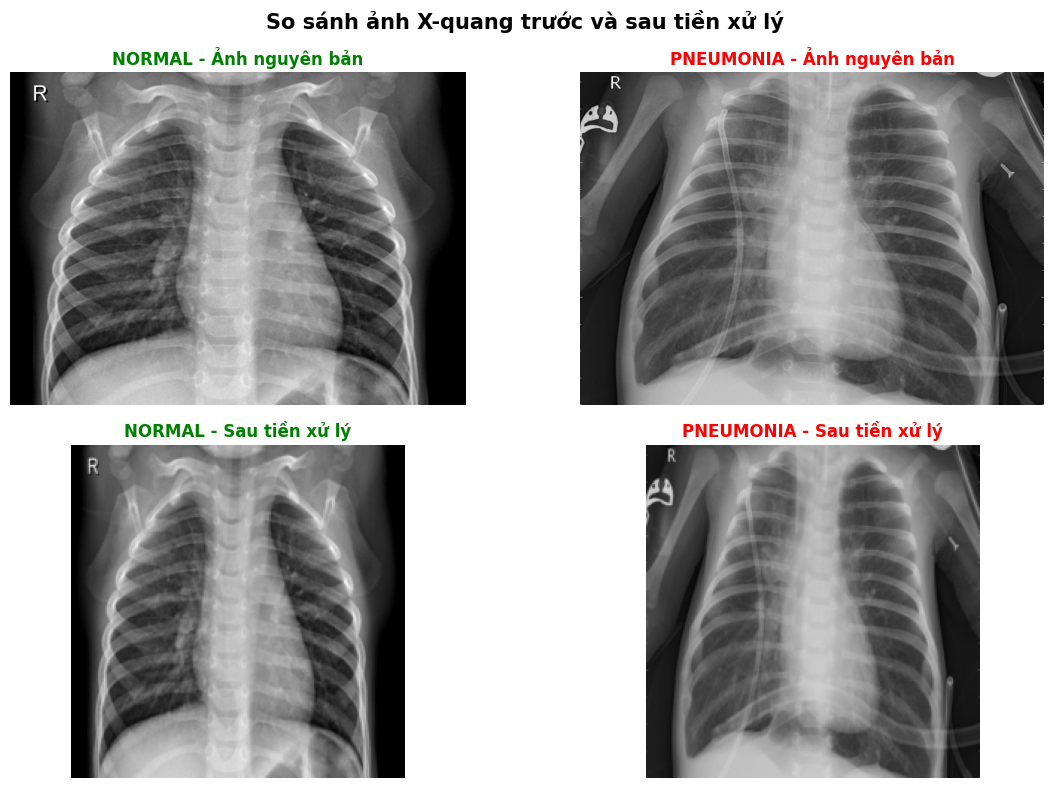


✅ Đã lưu hình tại: ./xray_before_after_preprocessing.png


In [17]:
# ============================================================
# LẤY 2 ẢNH TỪ DỮ LIỆU ĐÃ RESPLIT
# GỒM: 1 ẢNH NORMAL + 1 ẢNH PNEUMONIA
# HIỂN THỊ: ẢNH NGUYÊN BẢN VÀ ẢNH SAU TIỀN XỬ LÝ
# ============================================================

def get_first_image_path(folder_path):
    """
    Lấy ảnh đầu tiên trong thư mục.
    """
    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(image_files) == 0:
        raise FileNotFoundError(f"Không tìm thấy ảnh trong thư mục: {folder_path}")

    return os.path.join(folder_path, image_files[0])


def denormalize_tensor(tensor_img):
    """
    Đảo Normalize để hiển thị ảnh sau tiền xử lý.
    Tensor đầu vào có dạng C x H x W.
    """
    img = tensor_img.clone().detach().cpu()
    img = img.permute(1, 2, 0).numpy()

    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)

    img = img * std + mean
    img = np.clip(img, 0, 1)

    return img


# Có thể lấy từ train, val hoặc test
# Nên lấy từ test để minh họa dữ liệu đánh giá
split = "test"

normal_dir = os.path.join(RESPLIT_ROOT, split, "NORMAL")
pneumonia_dir = os.path.join(RESPLIT_ROOT, split, "PNEUMONIA")

normal_path = get_first_image_path(normal_dir)
pneumonia_path = get_first_image_path(pneumonia_dir)

print("Ảnh NORMAL được lấy từ:")
print(normal_path)

print("\nẢnh PNEUMONIA được lấy từ:")
print(pneumonia_path)

# Đọc ảnh nguyên bản
normal_original = Image.open(normal_path).convert("RGB")
pneumonia_original = Image.open(pneumonia_path).convert("RGB")

# Tiền xử lý ảnh
normal_processed_tensor = val_transform(normal_original)
pneumonia_processed_tensor = val_transform(pneumonia_original)

# Đảo Normalize để hiển thị ảnh sau xử lý
normal_processed_img = denormalize_tensor(normal_processed_tensor)
pneumonia_processed_img = denormalize_tensor(pneumonia_processed_tensor)

# Hiển thị 4 ảnh
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(normal_original)
plt.title("NORMAL - Ảnh nguyên bản", fontsize=12, fontweight="bold", color="green")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(pneumonia_original)
plt.title("PNEUMONIA - Ảnh nguyên bản", fontsize=12, fontweight="bold", color="red")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(normal_processed_img)
plt.title("NORMAL - Sau tiền xử lý", fontsize=12, fontweight="bold", color="green")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(pneumonia_processed_img)
plt.title("PNEUMONIA - Sau tiền xử lý", fontsize=12, fontweight="bold", color="red")
plt.axis("off")

plt.suptitle(
    "So sánh ảnh X-quang trước và sau tiền xử lý",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

# Lưu hình để đưa vào Word
output_path = "./xray_before_after_preprocessing.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("\n✅ Đã lưu hình tại:", output_path)